## Smart Crop Recommendation

In [29]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import warnings
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold
)
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)
from sklearn.svm import SVC
import xgboost as xgb
warnings.filterwarnings('ignore')

In [31]:
if os.path.exists('Crop_recommendation.csv'):
    df = pd.read_csv('Crop_recommendation.csv')
    print('Dataset imported successfully')
else:
    print('Dataset not found')

Dataset imported successfully


#### Exploratory Data Analysis

In [65]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [66]:
df.shape

(2200, 8)

This dataset consists of **2200 rows** in total.

Each row has **8** columns representing **Nitrogen, Phosphorous, Potassium, Temperature, Humidity, PH, Rainfall and Label (target)**

Nitrogen, Phosphorous and Potassium values represent the NPK values in the soil. Temperature, humidity and rainfall are the average values of the sorroundings environment respectively. PH is the PH value present in the soil. 

The Label column tells us the type of crop that's best suited to grow based on these conditions. Label is the value we will be predicting

In [75]:
cols = df.columns

print('Columns: \n')

for col in cols:
    print(col)

Columns: 

N
P
K
temperature
humidity
ph
rainfall
label


In [68]:
crops = df['label'].unique()

print('crops: \n')

for crop in crops:
    print(crop)

crops: 

rice
maize
chickpea
kidneybeans
pigeonpeas
mothbeans
mungbean
blackgram
lentil
pomegranate
banana
mango
grapes
watermelon
muskmelon
apple
orange
papaya
coconut
cotton
jute
coffee


In [69]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

In [70]:
# Class Distribution

df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

The dataset appears balanced.

That is very important because:

- Model bias reduces
- No major imbalance handling required

<Axes: >

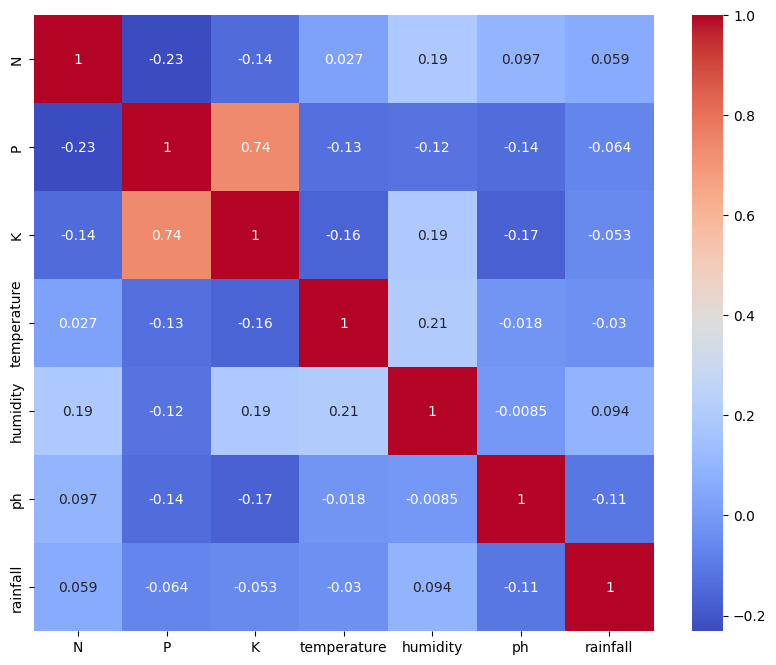

In [71]:
numeric_df = df.select_dtypes(include='number')  # Select numeric columns only

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

In [72]:
features = df[['N', 'P','K','temperature', 'humidity', 'ph', 'rainfall']]
target = df['label']

In [73]:
# Initializing empty lists to append all model's name and corresponding accuracy

acc = []
model = []

In [74]:
# Splitting into train and test data

from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(features, target, test_size = 0.2, random_state = 2)

### 1. Decision Tree

In [42]:
# Parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Base model
dt = DecisionTreeClassifier(random_state=2)

# Grid Search
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid_search.fit(Xtrain, Ytrain)

# Best model
best_dt = grid_search.best_estimator_

# Prediction
predicted_values = best_dt.predict(Xtest)

# Accuracy
x = accuracy_score(Ytest, predicted_values)

acc.append(x)
model.append('Decision Tree')

print("Best Parameters:", grid_search.best_params_)
print("Decision Tree Accuracy:", x * 100)

print(classification_report(Ytest, predicted_values))

Best Parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 20}
Decision Tree Accuracy: 97.72727272727273
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       0.93      0.88      0.90        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.85      1.00      0.92        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       0.91      0.91      0.91        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       0.90      0.95      0.92        19
    mungbean       1.00      1.00      1.00

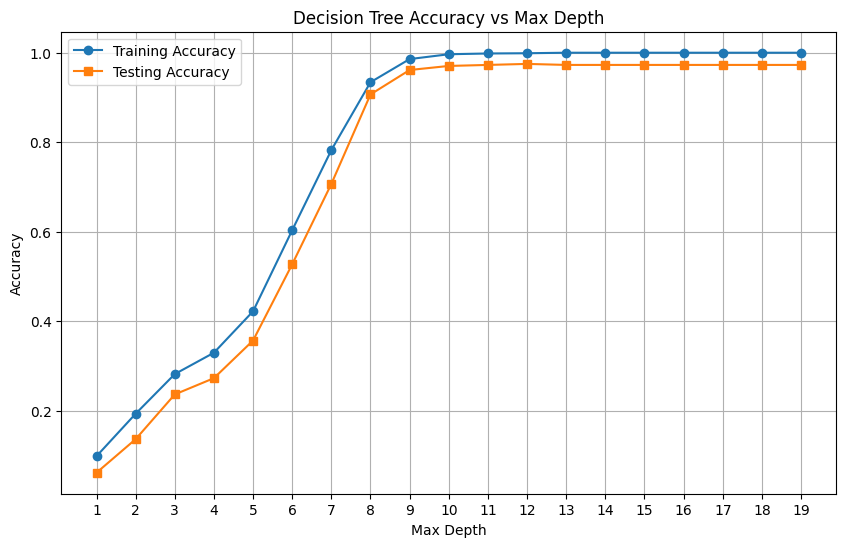

In [43]:
train_acc = []
test_acc = []

depths = range(1, 20)

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=2)
    dt.fit(Xtrain, Ytrain)

    train_acc.append(dt.score(Xtrain, Ytrain))
    test_acc.append(dt.score(Xtest, Ytest))

plt.figure(figsize=(10, 6))

plt.plot(depths, train_acc, marker='o', label='Training Accuracy')
plt.plot(depths, test_acc, marker='s', label='Testing Accuracy')

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Max Depth")

plt.xticks(depths)
plt.legend()
plt.grid(True)

plt.show()

- Training accuracy steadily increases and reaches nearly 100%
- Testing accuracy also increases and stabilizes around 97–98%
- After depth 9–10, the testing curve becomes almost flat

That means:

- depths below 6 were underfitting
- depths around 8–10 captured the important patterns

In [44]:
# Cross validation score (Decision Tree)

score = cross_val_score(best_dt, features, target, cv = 5)

print(score)
print("Average CV Score:", score.mean())

[0.99090909 0.98409091 0.99090909 0.99090909 0.98863636]
Average CV Score: 0.989090909090909


### 2. Guassian Naive Bayes

In [45]:
# Model
nb_model = GaussianNB()

# Train
nb_model.fit(Xtrain, Ytrain)

# Predict
predicted_values = nb_model.predict(Xtest)

# Accuracy
x = accuracy_score(Ytest, predicted_values)

acc.append(x)
model.append('Naive Bayes')

print("Naive Bayes Accuracy:", x * 100)

# Report
print(classification_report(Ytest, predicted_values))

Naive Bayes Accuracy: 99.0909090909091
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       1.00      1.00      1.00        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.88      1.00      0.93        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       1.00      1.00      1.00        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      1.00      1.00        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.0

In [46]:
# Cross validation score (NaiveBayes)

score = cross_val_score(nb_model, features, target, cv = 5)

print(score)
print("Average CV Score:", score.mean())

[0.99772727 0.99545455 0.99545455 0.99545455 0.99090909]
Average CV Score: 0.9950000000000001


Naive Bayes assumes: All features are independent

But in crop datasets: rainfall, humidity, temperature, soil nutrients are often correlated.

So this assumption is not fully true.

### 3. Support Vector Machine (SVM)

In [47]:
# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=2))
])

# Hyperparameter grid
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.1, 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# Grid Search
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(Xtrain, Ytrain)

# Best model
best_svm = grid.best_estimator_

# Prediction
predicted_values = best_svm.predict(Xtest)

# Accuracy
x = accuracy_score(Ytest, predicted_values)

acc.append(x)
model.append('SVM')

print("SVM Accuracy:", x * 100)

print(classification_report(Ytest, predicted_values))

SVM Accuracy: 97.72727272727273
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       1.00      1.00      1.00        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      0.95      0.98        22
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        18
        jute       0.83      0.89      0.86        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       0.96      1.00      0.98        23
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      0.95      0.97        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00      

In [48]:
# Cross validation score (SVM)
score = cross_val_score(best_svm, features, target, cv = 5)

print(score)
print("Average CV Score:", score.mean())

[0.98181818 0.98636364 0.98636364 0.98181818 0.99090909]
Average CV Score: 0.9854545454545456


### 4. Logistic Refression

In [49]:
# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        max_iter=1000,
        random_state=2
    ))
])

# Hyperparameter grid
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__solver': ['lbfgs', 'liblinear'],
}

# Grid Search
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(Xtrain, Ytrain)

# Best model
best_logreg = grid.best_estimator_

# Predict
predicted_values = best_logreg.predict(Xtest)

# Accuracy
x = accuracy_score(Ytest, predicted_values)

acc.append(x)
model.append('Logistic Regression')

# Results
print("Logistic Regression Accuracy:", x * 100)

print(classification_report(Ytest, predicted_values))

Logistic Regression Accuracy: 97.5
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       0.94      1.00      0.97        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        18
        jute       0.84      0.93      0.88        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       0.96      1.00      0.98        23
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      0.89      0.94        19
    mungbean       0.96      1.00      0.98        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1.00   

In [50]:
# Cross validation score (Logistic Regression)

score = cross_val_score(best_logreg, features, target, cv = 5)

print(score)
print("Average CV Score:", score.mean())

[0.97727273 0.97954545 0.98181818 0.98181818 0.98863636]
Average CV Score: 0.9818181818181818


### 5. Random Forest

In [51]:
# Base model
rf = RandomForestClassifier(random_state=5)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(Xtrain, Ytrain)

# Best model
best_rf = grid.best_estimator_

# Prediction
predicted_values = best_rf.predict(Xtest)

# Accuracy
x = accuracy_score(Ytest, predicted_values)

acc.append(x)
model.append('Random Forest')

# Results
print("Random Forest Accuracy:", x * 100)

print(classification_report(Ytest, predicted_values))

Random Forest Accuracy: 99.0909090909091
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       1.00      1.00      1.00        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        18
        jute       0.88      1.00      0.93        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       1.00      1.00      1.00        23
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        26
   mothbeans       1.00      1.00      1.00        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      1.00      1

In [52]:
# Cross validation score (Random Forest)
score = cross_val_score(best_rf, features, target, cv = 5)

print(score)
print("Average CV Score:", score.mean())

[0.99772727 0.99318182 0.99545455 0.99545455 0.99090909]
Average CV Score: 0.9945454545454545


### 6. XGBoost

In [53]:
# Encode target labels
le = LabelEncoder()

Ytrain_encoded = le.fit_transform(Ytrain)
Ytest_encoded = le.transform(Ytest)

# XGBoost Model
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=2
)

xgb_model.fit(
    Xtrain,
    Ytrain_encoded,
    eval_set=[(Xtest, Ytest_encoded)],
    verbose=False
)

# Predict
predicted_values = xgb_model.predict(Xtest)

# Accuracy
x = accuracy_score(Ytest_encoded, predicted_values)

acc.append(x)
model.append('XGBoost')

# Results
print("Best Iteration:", xgb_model.best_iteration)

print("XGBoost Accuracy:", x * 100)

print(classification_report(Ytest_encoded, predicted_values))

Best Iteration: 497
XGBoost Accuracy: 99.0909090909091
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        21
           4       1.00      1.00      1.00        21
           5       0.96      1.00      0.98        22
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        18
           8       0.93      0.96      0.95        28
           9       1.00      1.00      1.00        14
          10       0.96      1.00      0.98        23
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        26
          13       1.00      0.95      0.97        19
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        23
          16       1.00   

In [54]:
# Encode target labels
le = LabelEncoder()

target_encoded = le.fit_transform(target)

# XGBoost Model
XB = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
scores = cross_val_score(
    XB,
    features,
    target_encoded,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

# Results
print("Cross Validation Scores:", scores)

print("Average CV Accuracy:", scores.mean())

Cross Validation Scores: [0.99090909 0.98863636 0.99090909 0.99545455 0.99545455]
Average CV Accuracy: 0.9922727272727274


### 7. KNN

In [55]:
# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Parameter grid
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# Grid Search
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(Xtrain, Ytrain)

# Best model
best_knn = grid.best_estimator_

# Predict
y_pred = best_knn.predict(Xtest)

# Accuracy
accuracy = accuracy_score(Ytest, y_pred)

acc.append(accuracy)
model.append('KNN')

# Results
print("KNN Accuracy:", accuracy * 100)

print(classification_report(Ytest, y_pred))

KNN Accuracy: 96.5909090909091
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        13
      banana       1.00      1.00      1.00        17
   blackgram       0.89      1.00      0.94        16
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        22
      cotton       0.91      1.00      0.95        20
      grapes       1.00      1.00      1.00        18
        jute       0.84      0.93      0.88        28
 kidneybeans       1.00      1.00      1.00        14
      lentil       0.96      0.96      0.96        23
       maize       1.00      0.90      0.95        21
       mango       0.93      1.00      0.96        26
   mothbeans       1.00      0.79      0.88        19
    mungbean       1.00      1.00      1.00        24
   muskmelon       1.00      1.00      1.00        23
      orange       1.00      0.97      0.98       

In [56]:
# Pipeline
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=5,
        metric='minkowski',
        p=2
    ))
])

# Stratified K-Fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross Validation
scores = cross_val_score(
    knn_pipeline,
    features,
    target,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

# Results
print("Cross Validation Scores:", scores)

print("Average CV Accuracy:", scores.mean())

Cross Validation Scores: [0.97045455 0.975      0.97954545 0.95909091 0.97272727]
Average CV Accuracy: 0.9713636363636363


### Accuracy Comparison

                 Model  Accuracy  Precision    Recall  F1-Score
1          Naive Bayes  0.990909   0.992045  0.990909  0.990563
5              XGBoost  0.990909   0.991259  0.990909  0.990836
4        Random Forest  0.990909   0.992045  0.990909  0.990563
2                  SVM  0.977273   0.977779  0.977273  0.977297
0        Decision Tree  0.977273   0.979070  0.977273  0.976664
3  Logistic Regression  0.975000   0.975770  0.975000  0.974386
6                  KNN  0.965909   0.967729  0.965909  0.965519


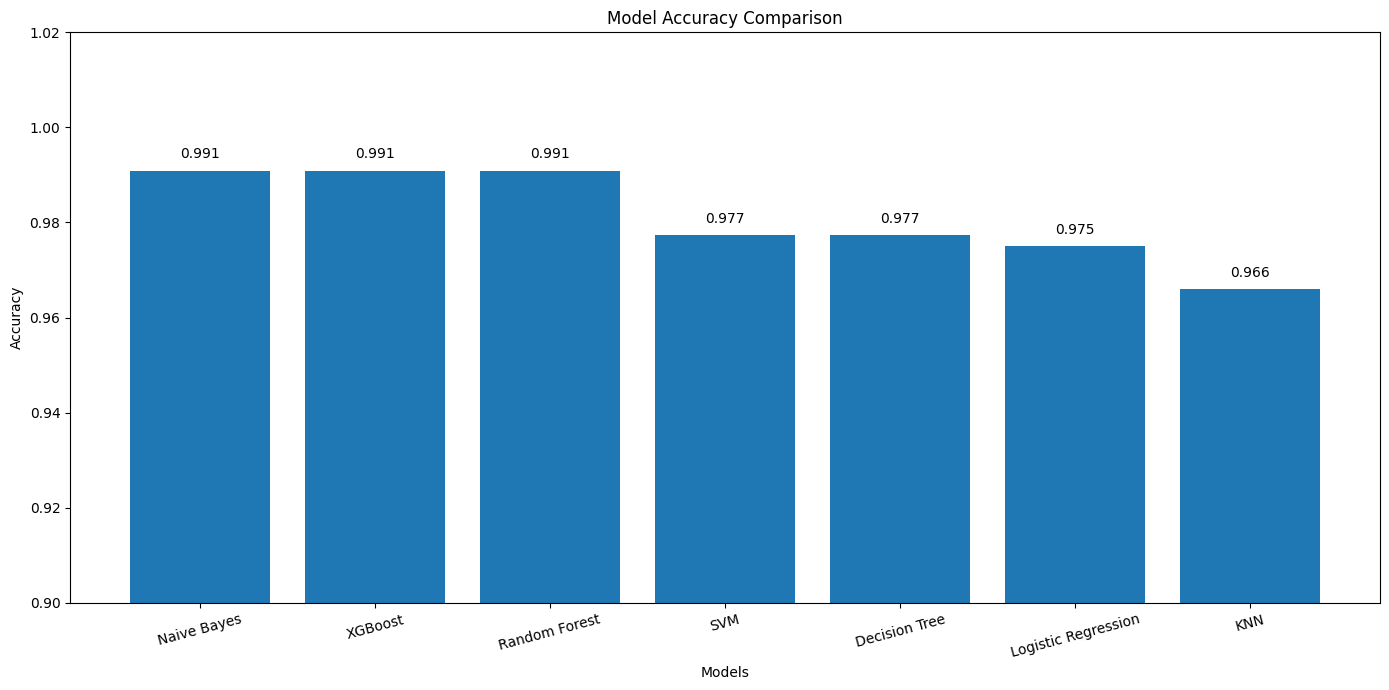

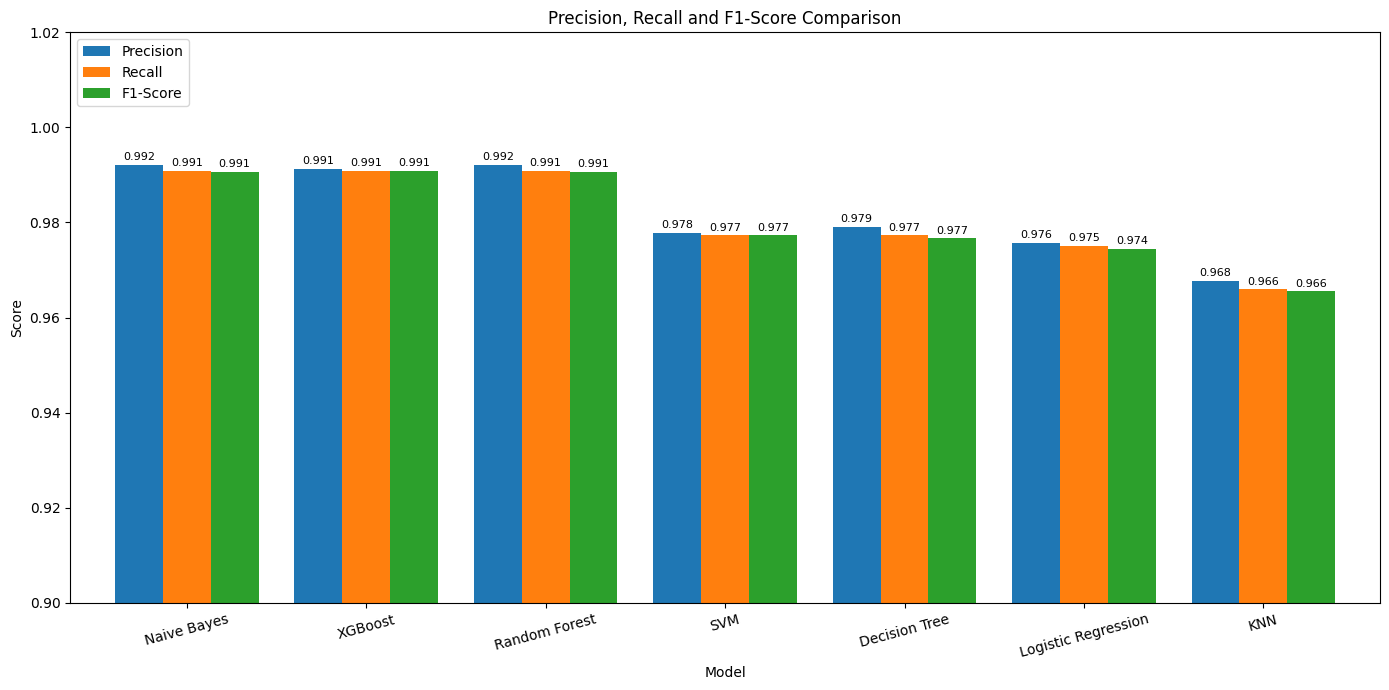

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Generate Predictions

dt_predictions = best_dt.predict(Xtest)
nb_predictions = nb_model.predict(Xtest)
svm_predictions = best_svm.predict(Xtest)
logreg_predictions = best_logreg.predict(Xtest)
rf_predictions = best_rf.predict(Xtest)
xgb_predictions = le.inverse_transform(
    xgb_model.predict(Xtest)
)
knn_predictions = best_knn.predict(Xtest)

# Store Predictions

models_data = {
    "Decision Tree": dt_predictions,
    "Naive Bayes": nb_predictions,
    "SVM": svm_predictions,
    "Logistic Regression": logreg_predictions,
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions,
    "KNN": knn_predictions
}

# Calculate Metrics

results = []

# Convert true labels to string
y_true_str = [str(label) for label in Ytest]

for model_name, preds in models_data.items():

    preds_str = [str(label) for label in preds]

    accuracy = accuracy_score(
        y_true_str,
        preds_str
    )

    precision = precision_score(
        y_true_str,
        preds_str,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true_str,
        preds_str,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true_str,
        preds_str,
        average="weighted",
        zero_division=0
    )

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

# Create DataFrame

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

# Sort by accuracy
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

# ACCURACY COMPARISON CHART

plt.figure(figsize=(14, 7))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.ylim(0.9, 1.02)

# Add values on top of bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# PRECISION / RECALL / F1 BAR CHART

ax = results_df.set_index("Model")[
    ["Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

plt.ylabel("Score")
plt.title("Precision, Recall and F1-Score Comparison")
plt.xticks(rotation=15)
plt.ylim(0.9, 1.02)

# Add labels on grouped bars
for container in ax.containers:

    ax.bar_label(
        container,
        fmt='%.3f',
        padding=2,
        fontsize=8
    )

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Saving Trained Random Forest Model

In [58]:
import pickle

# Dump the trained Random Forest classifier with Pickle
RF_pkl_filename = "RF.pkl"
with open(RF_pkl_filename, "wb") as file:
    pickle.dump(best_rf, file)

print("Random Forest model saved successfully to RF.pkl")


Random Forest model saved successfully to RF.pkl


### Confusion Matrix for Best Model (Random Forest)

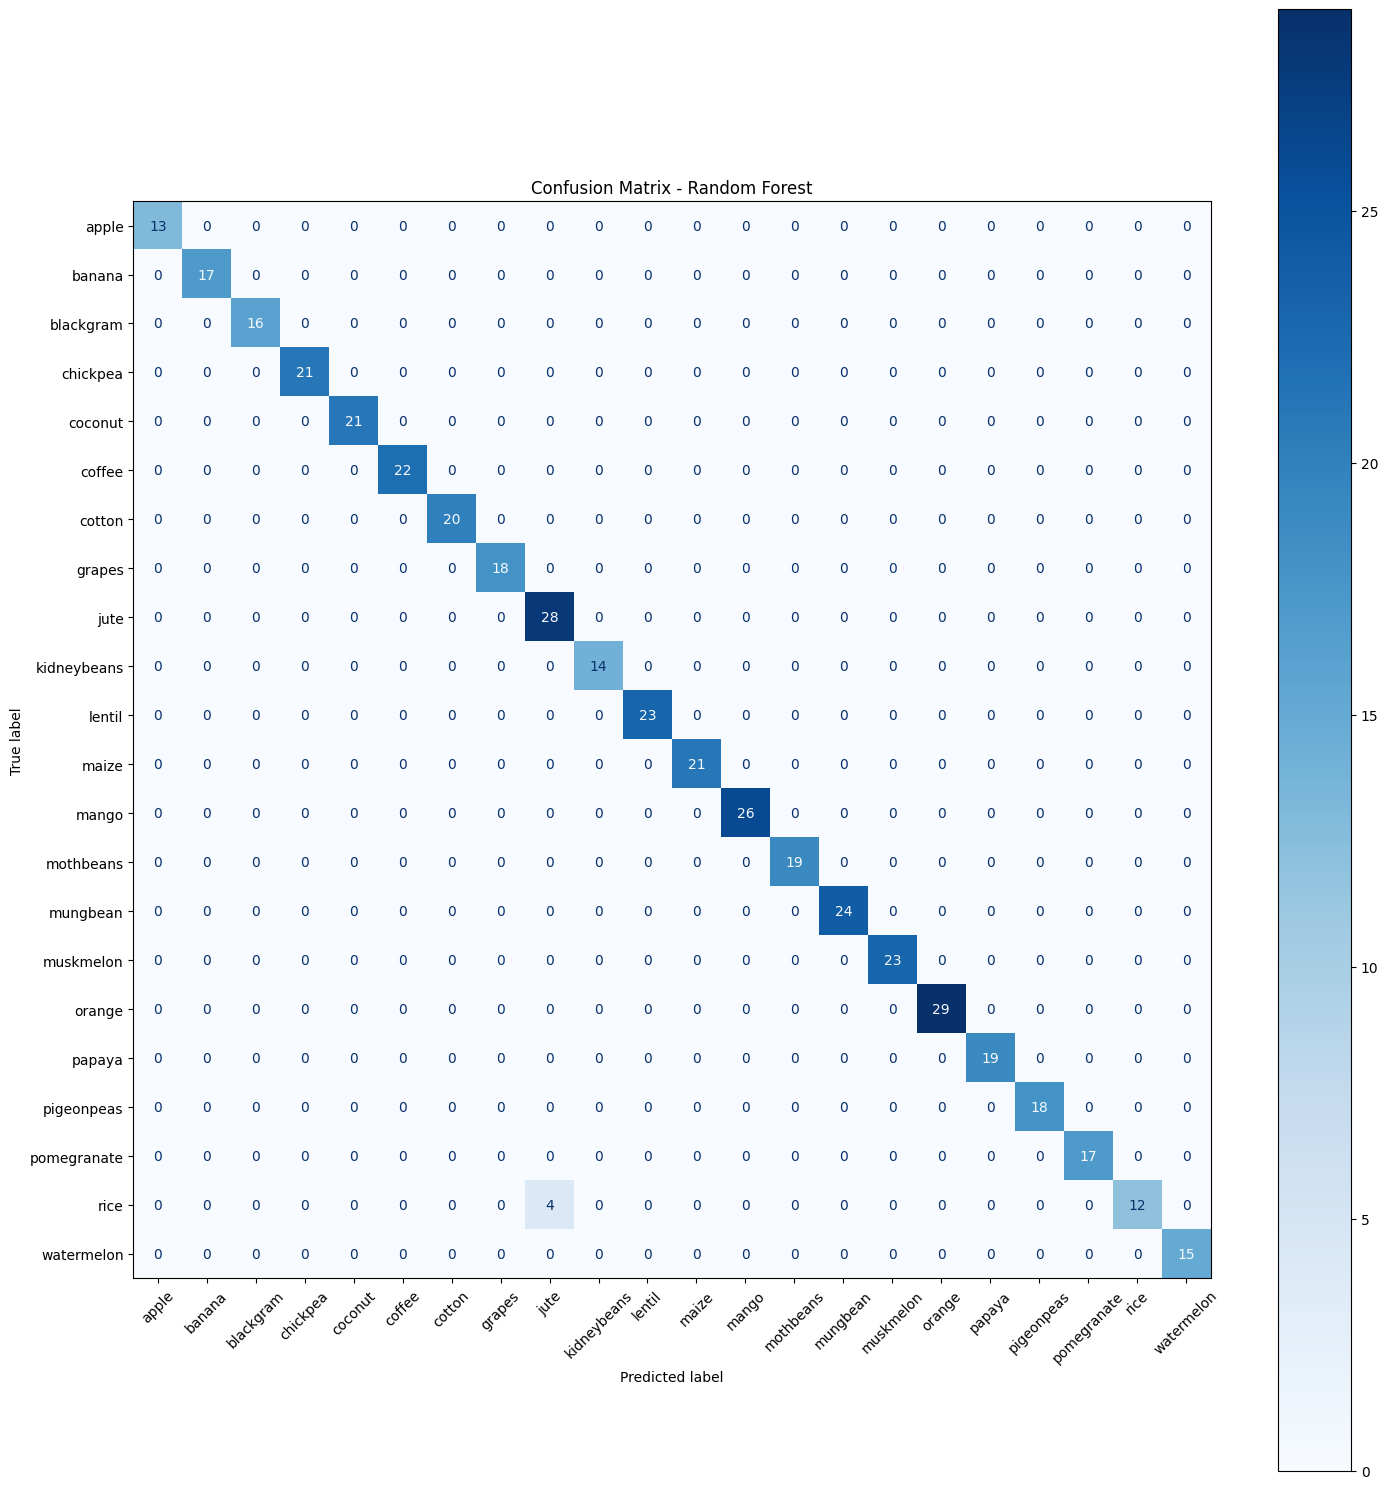

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Plot Confusion Matrix for Random Forest
rf_predictions = best_rf.predict(Xtest)
cm = confusion_matrix(Ytest, rf_predictions, labels=best_rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)

fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()


### Making a Prediction

In [60]:
# Data format: [N, P, K, temperature, humidity, ph, rainfall]
data = np.array([[104, 18, 30, 23.603016, 60.3, 6.7, 140.91]])
prediction = best_rf.predict(data)
print("Predicted Crop:", prediction[0])


Predicted Crop: coffee


### Stacked Ensemble Model

In [61]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    StackingClassifier
)

# Features
X = df[[
    'N',
    'P',
    'K',
    'temperature',
    'humidity',
    'ph',
    'rainfall'
]]

# Target
y = df['label']

# LABEL ENCODING
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# BASE MODEL 1 - RANDOM FOREST
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# BASE MODEL 2 - EXTRA TREES
et_model = ExtraTreesClassifier(
    n_estimators=400,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# BASE MODEL 3 - XGBOOST
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# BASE MODEL 4 - SVM PIPELINE
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        probability=True,
        C=20,
        gamma='scale',
        random_state=42
    ))
])

# META CLASSIFIER
meta_classifier = LogisticRegression(
    max_iter=2000,
    C=10,
    random_state=42
)

# STACKING CLASSIFIER
stacking_clf = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('et', et_model),
        ('xgb', xgb_model),
        ('svm', svm_model)
    ],
    final_estimator=meta_classifier,
    stack_method='predict_proba', # Use probabilities instead of class labels
    passthrough=True, # Important improvement
    cv=5,
    n_jobs=-1
)

# TRAIN MODEL
print("Training improved stacked ensemble...")

stacking_clf.fit(X_train, y_train)

# PREDICTIONS
y_pred = stacking_clf.predict(X_test)

# EVALUATION
accuracy = accuracy_score(y_test, y_pred)

print(f"\nImproved Stacked Ensemble Accuracy: {accuracy * 100:.2f}%")

# Convert labels back to crop names

y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# Classification Report
print("\nClassification Report:\n")

print(classification_report(
    y_test_labels,
    y_pred_labels
))


Training improved stacked ensemble...

Improved Stacked Ensemble Accuracy: 99.77%

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00     

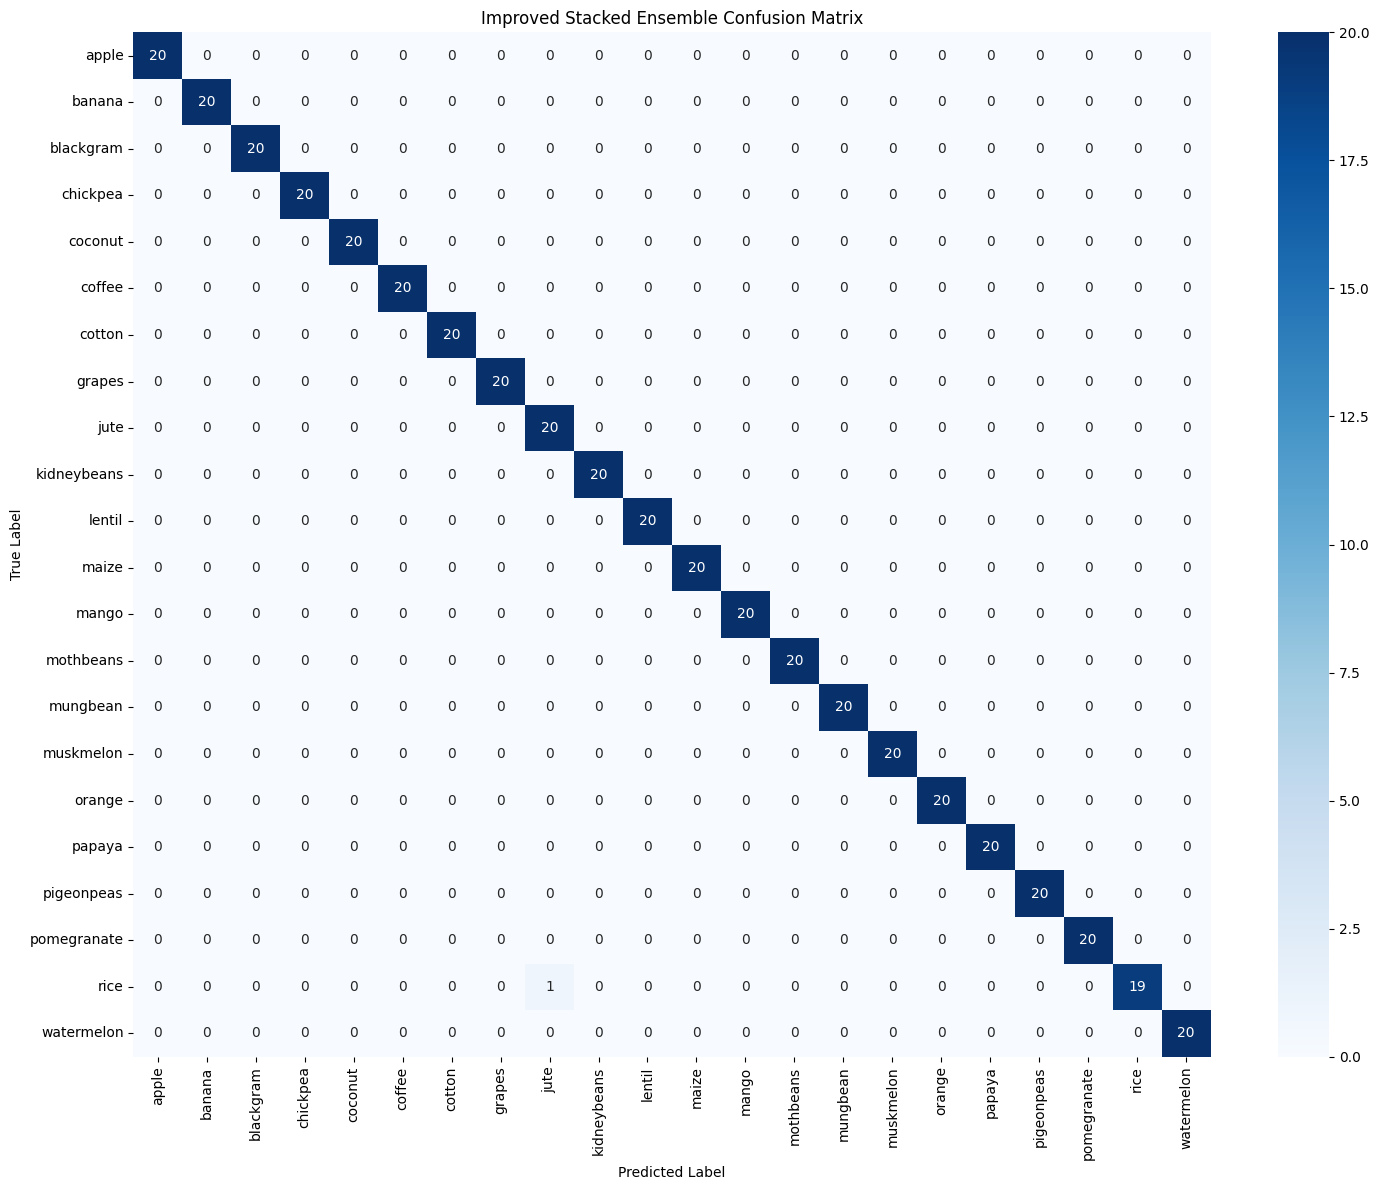

In [62]:
# CONFUSION MATRIX
cm = confusion_matrix(
    y_test_labels,
    y_pred_labels
)

plt.figure(figsize=(15, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Improved Stacked Ensemble Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [63]:
# SAVE MODEL
ensemble_model = {
    'stacking_clf': stacking_clf,
    'label_encoder': le,
    'is_sklearn_stack': True
}

model_path = "stacked_crop_model.pkl"

with open(model_path, 'wb') as f:
    pickle.dump(ensemble_model, f)

print(f"\nImproved model saved at: {model_path}")


Improved model saved at: stacked_crop_model.pkl


In [64]:
# STRATIFIED K-FOLD
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# CROSS VALIDATION
print("\nRunning Cross Validation...\n")

scores = cross_val_score(
    stacking_clf,
    X,
    y_encoded,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

# RESULTS
print("Cross Validation Scores:")

for i, score in enumerate(scores, start=1):

    print(f"Fold {i}: {score * 100:.4f}%")

print("\nAverage CV Accuracy:",
      round(scores.mean() * 100, 4), "%")

print("Standard Deviation:",
      round(scores.std() * 100, 4), "%")

# CONFIDENCE INTERVAL
lower_bound = (
    scores.mean() - scores.std()
) * 100

upper_bound = (
    scores.mean() + scores.std()
) * 100

print(f"\nExpected Accuracy Range: "
      f"{lower_bound:.4f}% - "
      f"{upper_bound:.4f}%")


Running Cross Validation...

Cross Validation Scores:
Fold 1: 99.7727%
Fold 2: 99.3182%
Fold 3: 99.7727%
Fold 4: 99.7727%
Fold 5: 99.0909%

Average CV Accuracy: 99.5455 %
Standard Deviation: 0.2875 %

Expected Accuracy Range: 99.2580% - 99.8329%
